# BDD100K Chip-Level OOD Showcase

Qualitative object-region OOD review on BDD100K.

This notebook treats BDD100K as an in-distribution dataset only: it trains a
classifier head on one subset of train object chips, fits chip-level OOD
detectors on a separate train-chip subset, then scores val chips for
qualitative inspection. It does not produce image-level OOD labels or metrics.
Because there is no explicit OOD split here, "OOD" means high detector score
and "ID-like" means low detector score.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import os
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path

# --- Edit these paths for your machine, or set OODKIT_DATASETS ---------------
DATASETS_ROOT = Path(os.environ.get("OODKIT_DATASETS", "/datasets"))
BDD_ROOT = DATASETS_ROOT / "bdd100k"
BDD_IMAGE_ROOT = BDD_ROOT / "images" / "100k"
BDD_LABEL_ROOT = BDD_ROOT / "labels"
CHECKPOINT_DIR = Path(os.environ.get(
    "OODKIT_BDD_CHIP_CHECKPOINT",
    "../outputs/bdd100k_embedder_checkpoint",
))
REUSE_CHECKPOINT = True
SAVE_CHECKPOINT = True

BACKBONE = "dinov2-small"
# "head" trains only the classifier head. "full" finetunes the backbone too.
TRAIN_MODE = "full"
HEAD_EPOCHS = 8
HEAD_LR = 5e-4
BACKBONE_LR_RATIO = 0.05
BATCH_SIZE = 32
NUM_WORKERS = 4  # Use 0 in notebooks to avoid multiprocessing cleanup noise.
PIN_MEMORY = True
PERSISTENT_WORKERS = True

SEED = 42

# Keep first runs practical. These fractions select source images, not chips, so
# all chips from a selected image stay together.
HEAD_TRAIN_IMAGE_FRACTION = 0.35
DETECTOR_TRAIN_IMAGE_FRACTION = 0.35
VAL_IMAGE_FRACTION = 0.50

# Filtering small boxes reduces noisy chips and keeps runtime sane.
MIN_BOX_SIDE = 8
MIN_CHIP_SIZE = 32

# Classes to show in qualitative grids. Set to None to auto-pick frequent val classes.
FOCUS_CLASSES = ["car", "person", "traffic sign"]
GALLERY_DETECTORS = ["Mahalanobis", "ViM"]
TOP_AUTO_CLASSES = 3
GRID_K = 8

_DL_KW = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)


def _check_paths() -> None:
    required = [
        BDD_IMAGE_ROOT / "train",
        BDD_IMAGE_ROOT / "val",
        BDD_LABEL_ROOT / "bdd100k_labels_images_train.json",
        BDD_LABEL_ROOT / "bdd100k_labels_images_val.json",
    ]
    missing = [p for p in required if not p.exists()]
    if missing:
        print("Missing BDD100K paths - set OODKIT_DATASETS or update BDD_ROOT:", file=sys.stderr)
        for p in missing:
            print(f"  - {p}", file=sys.stderr)
        raise FileNotFoundError("Fix BDD100K paths.")


_check_paths()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageDraw

from oodkit.data.chip_dataset import ChipDataset, ChipImageAnn
from oodkit.data.chips import crop_chip, square_chip_regions
from oodkit.data.features import Features
from oodkit.detectors import Mahalanobis, ViM
from oodkit.embeddings.backbones import load_backbone
from oodkit.embeddings.embedder import Embedder
from oodkit.evaluation import ScoreBank
from oodkit.evaluation.plots import rank_grid

## BDD100K Chip Loader

BDD100K labels are JSON records keyed by image name. Each object label with a
`box2d` becomes one square chip. Category strings are mapped to contiguous
integer labels so the classifier head and class-conditional detectors share a
stable vocabulary.

In [3]:
@dataclass(frozen=True)
class BddLabelPaths:
    train: Path = BDD_LABEL_ROOT / "bdd100k_labels_images_train.json"
    val: Path = BDD_LABEL_ROOT / "bdd100k_labels_images_val.json"


def _load_bdd_json(path: Path) -> list[dict]:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError(f"Expected a list of image records in {path}")
    return data


def bdd_class_names(label_paths: list[Path]) -> list[str]:
    names: set[str] = set()
    for path in label_paths:
        for image_rec in _load_bdd_json(path):
            for obj in image_rec.get("labels", []):
                if "box2d" in obj and obj.get("category"):
                    names.add(str(obj["category"]))
    return sorted(names)


def bdd_chip_annotations(
    label_json: Path,
    image_dir: Path,
    *,
    class_to_idx: dict[str, int],
    group: str,
    min_box_side: float = MIN_BOX_SIDE,
) -> list[ChipImageAnn]:
    records = _load_bdd_json(label_json)
    annotations: list[ChipImageAnn] = []
    missing_images: list[str] = []

    for image_rec in records:
        image_name = str(image_rec["name"])
        image_path = image_dir / image_name
        if not image_path.exists():
            missing_images.append(image_name)
            continue

        boxes: list[list[float]] = []
        labels: list[int] = []
        for obj in image_rec.get("labels", []):
            box = obj.get("box2d")
            category = obj.get("category")
            if box is None or category not in class_to_idx:
                continue
            x1, y1, x2, y2 = map(float, (box["x1"], box["y1"], box["x2"], box["y2"]))
            if min(x2 - x1, y2 - y1) < min_box_side:
                continue
            boxes.append([x1, y1, x2, y2])
            labels.append(class_to_idx[str(category)])

        if boxes:
            annotations.append(
                ChipImageAnn(
                    image_path=str(image_path),
                    boxes=np.asarray(boxes, dtype=np.float64),
                    labels=np.asarray(labels, dtype=np.int64),
                    group=group,
                    image_id=Path(image_name).stem,
                )
            )

    if missing_images:
        print(f"[warn] {label_json.name}: skipped {len(missing_images)} missing images")
    return annotations


label_paths = BddLabelPaths()
class_names = bdd_class_names([label_paths.train, label_paths.val])
class_to_idx = {name: i for i, name in enumerate(class_names)}
print(f"BDD classes ({len(class_names)}): {class_names}")

BDD classes (10): ['bike', 'bus', 'car', 'motor', 'person', 'rider', 'traffic light', 'traffic sign', 'train', 'truck']


In [4]:
_, processor, _ = load_backbone(BACKBONE)

train_anns_full = bdd_chip_annotations(
    label_paths.train,
    BDD_IMAGE_ROOT / "train",
    class_to_idx=class_to_idx,
    group="bdd_train",
)
val_anns_full = bdd_chip_annotations(
    label_paths.val,
    BDD_IMAGE_ROOT / "val",
    class_to_idx=class_to_idx,
    group="bdd_val",
)

print(f"Train source images with chips: {len(train_anns_full)}")
print(f"Val source images with chips:   {len(val_anns_full)}")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Train source images with chips: 69862
Val source images with chips:   9999


## Subsample By Image

The head-training and detector-fitting pools are disjoint train-image subsets.
Val is held out for qualitative scoring and inspection.

In [5]:
def _take_annotations(anns: list[ChipImageAnn], image_indices: np.ndarray) -> list[ChipImageAnn]:
    return [anns[int(i)] for i in image_indices]


def bdd_image_strata(label_json: Path, annotations: list[ChipImageAnn]) -> np.ndarray:
    """Return one stratification key per annotation from BDD image attributes."""
    records = _load_bdd_json(label_json)
    by_id = {Path(str(r["name"])).stem: r for r in records}
    strata: list[str] = []
    for ann in annotations:
        rec = by_id.get(str(ann.image_id))
        attrs = rec.get("attributes", {}) if rec is not None else {}
        timeofday = attrs.get("timeofday", "unknown")
        weather = attrs.get("weather", "unknown")
        scene = attrs.get("scene", "unknown")
        strata.append(f"timeofday={timeofday}|weather={weather}|scene={scene}")
    return np.asarray(strata, dtype=object)


def _stratified_indices(strata: np.ndarray, fraction: float, *, seed: int) -> np.ndarray:
    if not (0 < fraction <= 1):
        raise ValueError("fraction must be in (0, 1]")
    rng = np.random.default_rng(seed)
    picks: list[np.ndarray] = []
    for key in np.unique(strata):
        group_idx = np.nonzero(strata == key)[0]
        if fraction >= 1.0:
            picks.append(group_idx)
            continue
        k = max(1, int(round(len(group_idx) * fraction)))
        k = min(k, len(group_idx))
        picks.append(rng.choice(group_idx, size=k, replace=False))
    return np.sort(np.concatenate(picks)) if picks else np.array([], dtype=np.int64)


def train_detector_split_indices(
    strata: np.ndarray,
    *,
    head_fraction: float,
    detector_fraction: float,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    if not (0 < head_fraction <= 1 and 0 < detector_fraction <= 1):
        raise ValueError("fractions must be in (0, 1]")
    rng = np.random.default_rng(seed)
    head_chunks: list[np.ndarray] = []
    detector_chunks: list[np.ndarray] = []
    for key in np.unique(strata):
        group_idx = np.nonzero(strata == key)[0]
        order = rng.permutation(group_idx)
        n_head = max(1, int(round(len(order) * head_fraction)))
        n_detector = max(1, int(round(len(order) * detector_fraction)))
        if n_head + n_detector > len(order):
            n_head = min(n_head, len(order))
            n_detector = max(0, len(order) - n_head)
        head_chunks.append(order[:n_head])
        if n_detector > 0:
            detector_chunks.append(order[n_head:n_head + n_detector])
    head = np.sort(np.concatenate(head_chunks)) if head_chunks else np.array([], dtype=np.int64)
    detector = np.sort(np.concatenate(detector_chunks)) if detector_chunks else np.array([], dtype=np.int64)
    return head, detector


def print_stratum_counts(name: str, strata: np.ndarray, idx: np.ndarray, *, top_k: int = 12) -> None:
    selected = strata[idx]
    keys, counts = np.unique(selected, return_counts=True)
    order = np.argsort(-counts)
    print(f"{name} strata ({len(keys)} groups):")
    for i in order[:top_k]:
        print(f"  {counts[i]:5d}  {keys[i]}")
    if len(keys) > top_k:
        print(f"  ... {len(keys) - top_k} more")


train_strata = bdd_image_strata(label_paths.train, train_anns_full)
val_strata = bdd_image_strata(label_paths.val, val_anns_full)

head_idx, detector_idx = train_detector_split_indices(
    train_strata,
    head_fraction=HEAD_TRAIN_IMAGE_FRACTION,
    detector_fraction=DETECTOR_TRAIN_IMAGE_FRACTION,
    seed=SEED,
)
val_idx = _stratified_indices(val_strata, VAL_IMAGE_FRACTION, seed=SEED + 1)

head_ds = ChipDataset(
    _take_annotations(train_anns_full, head_idx),
    processor,
    min_chip_size=MIN_CHIP_SIZE,
    class_names=class_names,
)
detector_train_ds = ChipDataset(
    _take_annotations(train_anns_full, detector_idx),
    processor,
    min_chip_size=MIN_CHIP_SIZE,
    class_names=class_names,
)
val_ds = ChipDataset(
    _take_annotations(val_anns_full, val_idx),
    processor,
    min_chip_size=MIN_CHIP_SIZE,
    class_names=class_names,
)

print(f"Head train:     {len(head_idx)} images | {len(head_ds)} chips")
print(f"Detector train: {len(detector_idx)} images | {len(detector_train_ds)} chips")
print(f"Val scored:     {len(val_idx)} images | {len(val_ds)} chips")
print()
print_stratum_counts("Head train", train_strata, head_idx)
print_stratum_counts("Detector train", train_strata, detector_idx)
print_stratum_counts("Val scored", val_strata, val_idx)

Head train:     24464 images | 428543 chips
Detector train: 24446 images | 430642 chips
Val scored:     5013 images | 89379 chips

Head train strata (125 groups):
   5274  timeofday=night|weather=clear|scene=city street
   2323  timeofday=daytime|weather=clear|scene=city street
   2154  timeofday=night|weather=clear|scene=highway
   1749  timeofday=daytime|weather=undefined|scene=city street
   1542  timeofday=daytime|weather=overcast|scene=city street
   1251  timeofday=daytime|weather=clear|scene=highway
    778  timeofday=daytime|weather=partly cloudy|scene=city street
    745  timeofday=daytime|weather=clear|scene=residential
    687  timeofday=daytime|weather=overcast|scene=highway
    666  timeofday=daytime|weather=snowy|scene=city street
    624  timeofday=night|weather=snowy|scene=city street
    572  timeofday=daytime|weather=rainy|scene=city street
  ... 113 more
Detector train strata (107 groups):
   5274  timeofday=night|weather=clear|scene=city street
   2323  timeofday=da

## Train Head And Extract Features

If `CHECKPOINT_DIR` already contains a saved OODKit checkpoint, the notebook
loads the backbone and head from disk. Otherwise, `TRAIN_MODE="full"` finetunes
the backbone with a lower learning rate than the classifier head and saves the
result for later runs. Switch to `TRAIN_MODE="head"` for a faster frozen-backbone
run. The trained head provides logits for ViM and gives the embedding space a
BDD-specific class boundary.

In [6]:
checkpoint_files = [CHECKPOINT_DIR / name for name in ("meta.json", "backbone.pt", "head.pt")]
if REUSE_CHECKPOINT and all(p.exists() for p in checkpoint_files):
    print(f"Loading checkpoint from {CHECKPOINT_DIR}")
    embedder = Embedder.load(str(CHECKPOINT_DIR))
else:
    print(f"Training {TRAIN_MODE!r} model; checkpoint will be saved to {CHECKPOINT_DIR}")
    embedder = Embedder(backbone=BACKBONE)
    embedder.fit(
        head_ds,
        mode=TRAIN_MODE,
        epochs=HEAD_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=HEAD_LR,
        backbone_lr_ratio=BACKBONE_LR_RATIO,
        save=SAVE_CHECKPOINT,
        save_path=str(CHECKPOINT_DIR),
        **_DL_KW,
    )

Loading checkpoint from outputs/bdd100k_embedder_checkpoint


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [7]:
with warnings.catch_warnings(), contextlib.redirect_stderr(io.StringIO()):
    warnings.simplefilter("ignore")
    detector_train_res = embedder.extract(detector_train_ds, batch_size=BATCH_SIZE, **_DL_KW)
    val_res = embedder.extract(val_ds, batch_size=BATCH_SIZE, **_DL_KW)

assert detector_train_res.labels is not None
assert detector_train_res.logits is not None
assert val_res.labels is not None
assert val_res.logits is not None

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Detector train embeddings: {detector_train_res.embeddings.shape}")
print(f"Val embeddings:            {val_res.embeddings.shape}")

extracting:   0%|          | 0/13458 [00:00<?, ?it/s]

extracting:   0%|          | 0/2794 [00:00<?, ?it/s]

Detector train embeddings: (430642, 384)
Val embeddings:            (89379, 384)


## Fit Detectors

Mahalanobis uses class labels from the detector-training split. ViM uses the
fitted classifier head weights and logits.

In [8]:
train_feat = detector_train_res.to_features()
y_train = detector_train_res.labels

head = embedder._head  # noqa: SLF001 - no public accessor yet
assert head is not None
W = head.weight.detach().cpu().numpy()
b = head.bias.detach().cpu().numpy()

detectors = {}

maha = Mahalanobis(eps=1e-5)
maha.fit(train_feat, y=y_train)
detectors["Mahalanobis"] = maha

vim = ViM(W, b)
vim.fit(train_feat)
detectors["ViM"] = vim

val_feat = val_res.to_features()
chip_scores = {name: det.score(val_feat) for name, det in detectors.items()}

del train_feat, y_train, W, b

## Score Overview

Without a separate OOD split, this is descriptive: wide right tails are chips
that the detector considers unusual relative to the train-chip fit.

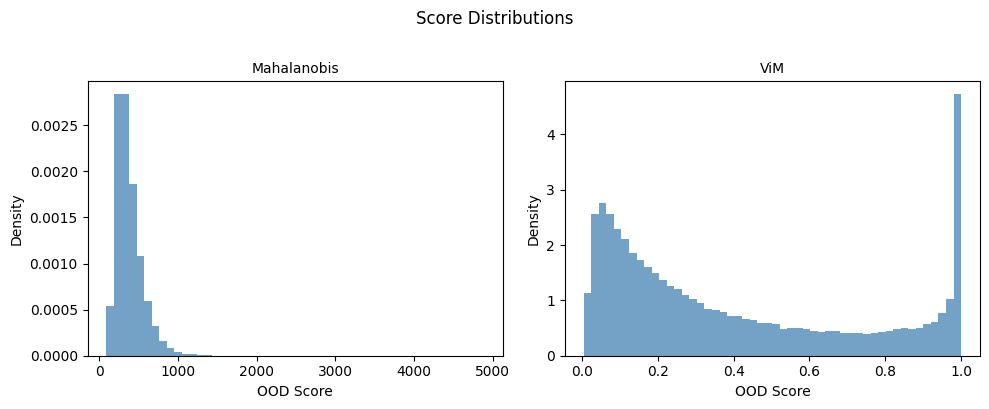

In [9]:
from oodkit.evaluation.plots import score_distributions

class_labels = np.asarray(val_res.labels, dtype=np.int64)
group_per_chip = val_strata[np.asarray(val_ds.chip_to_image, dtype=np.int64)]

chip_bank = ScoreBank(
    class_labels=class_labels,
    class_names=class_names,
    groups=group_per_chip,
)
for name, scores in chip_scores.items():
    chip_bank.add(name, scores)

score_distributions(chip_bank, kind="hist", n_bins=50)
plt.show()

In [10]:
import pandas as pd


def score_summary_by_group(min_chips: int = 100) -> pd.DataFrame:
    rows = []
    for group in np.unique(group_per_chip):
        mask = group_per_chip == group
        if int(mask.sum()) < min_chips:
            continue
        row = {"group": group, "n_chips": int(mask.sum())}
        for name, scores in chip_scores.items():
            row[f"{name}_mean"] = float(np.mean(scores[mask]))
            row[f"{name}_p10"] = float(np.percentile(scores[mask], 10))
            row[f"{name}_p90"] = float(np.percentile(scores[mask], 90))
        rows.append(row)
    return pd.DataFrame(rows).sort_values("n_chips", ascending=False)


score_summary_by_group().head(20)

,group,n_chips,Mahalanobis_mean,Mahalanobis_p10,Mahalanobis_p90,ViM_mean,ViM_p10,ViM_p90
32,timeofday=night|weather=clear|scene=city street,19176,377.671010,208.576825,596.033920,0.399991,0.054343,0.971851
14,timeofday=daytime|weather=clear|scene=city street,8159,383.686395,209.686304,604.629711,0.406335,0.051930,0.976526
33,timeofday=night|weather=clear|scene=highway,7454,373.820082,208.949912,585.927069,0.395596,0.054192,0.971688
29,timeofday=daytime|weather=undefined|scene=city...,6315,383.033600,207.517574,606.104196,0.409846,0.052921,0.979405
17,timeofday=daytime|weather=overcast|scene=city ...,5493,379.178114,209.601879,598.502293,0.404064,0.056725,0.974564
15,timeofday=daytime|weather=clear|scene=highway,4433,377.975115,208.959415,596.163302,0.397815,0.054763,0.969529
16,timeofday=daytime|weather=clear|scene=residential,3133,381.530202,210.271157,601.467948,0.405527,0.053975,0.973404
26,timeofday=daytime|weather=snowy|scene=city street,2562,377.629292,208.010233,603.905835,0.395557,0.054565,0.969312
20,timeofday=daytime|weather=partly cloudy|scene=...,2554,379.233359,211.494301,595.638049,0.393946,0.052668,0.956479
18,timeofday=daytime|weather=overcast|scene=highway,2268,374.823965,206.396529,597.217126,0.401047,0.052102,0.974631


In [11]:
id_counts = np.bincount(class_labels, minlength=len(class_names))
if FOCUS_CLASSES is None:
    focus_classes = [
        class_names[int(i)]
        for i in np.argsort(-id_counts)[:TOP_AUTO_CLASSES]
        if id_counts[int(i)] > 0
    ]
else:
    focus_classes = [c for c in FOCUS_CLASSES if c in class_names and id_counts[class_names.index(c)] > 0]

print("Focus classes:")
for cls_name in focus_classes:
    print(f"  {cls_name:<16s} {id_counts[class_names.index(cls_name)]} val chips")

Focus classes:
  car              50900 val chips
  person           6424 val chips
  traffic sign     16474 val chips


## Ranked Chip Galleries

For selected detector/class pairs, the OOD grid shows the highest-scoring val
chips; the ID-like grid shows the lowest-scoring chips. This is chip-level
qualitative review, not a benchmark metric.

In [12]:
combined_image_paths: list[str] = list(val_res.metadata["image_paths"])
combined_boxes = np.asarray(val_res.metadata["boxes"], dtype=np.float64)


class ChipImageLoader:
    """Sample-aligned on-demand chip cropper for rank_grid(images=...)."""

    def __init__(self, paths, boxes, *, min_chip_size: int = MIN_CHIP_SIZE):
        self._paths = paths
        self._boxes = boxes
        self._min_chip_size = min_chip_size

    def __getitem__(self, idx: int):
        image_np = np.asarray(Image.open(self._paths[idx]).convert("RGB"))
        return crop_chip(image_np, self._boxes[idx], min_chip_size=self._min_chip_size)


chip_images = ChipImageLoader(combined_image_paths, combined_boxes)

Mahalanobis | car | highest OOD scores


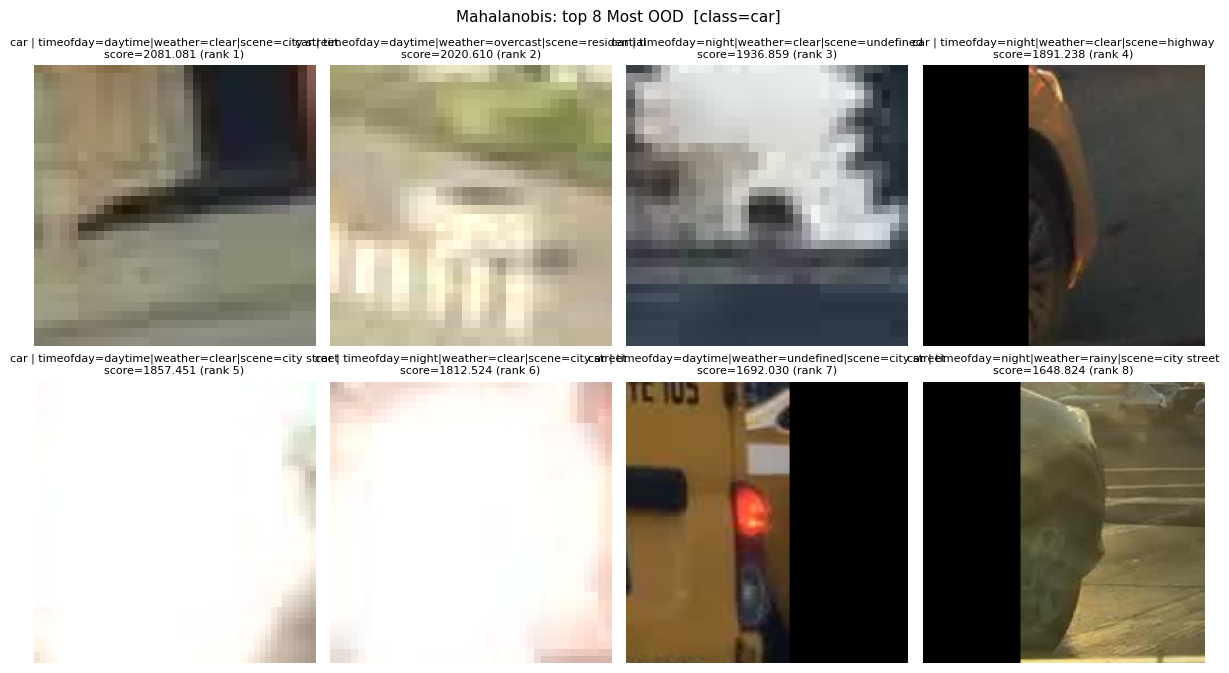

Mahalanobis | car | lowest OOD scores


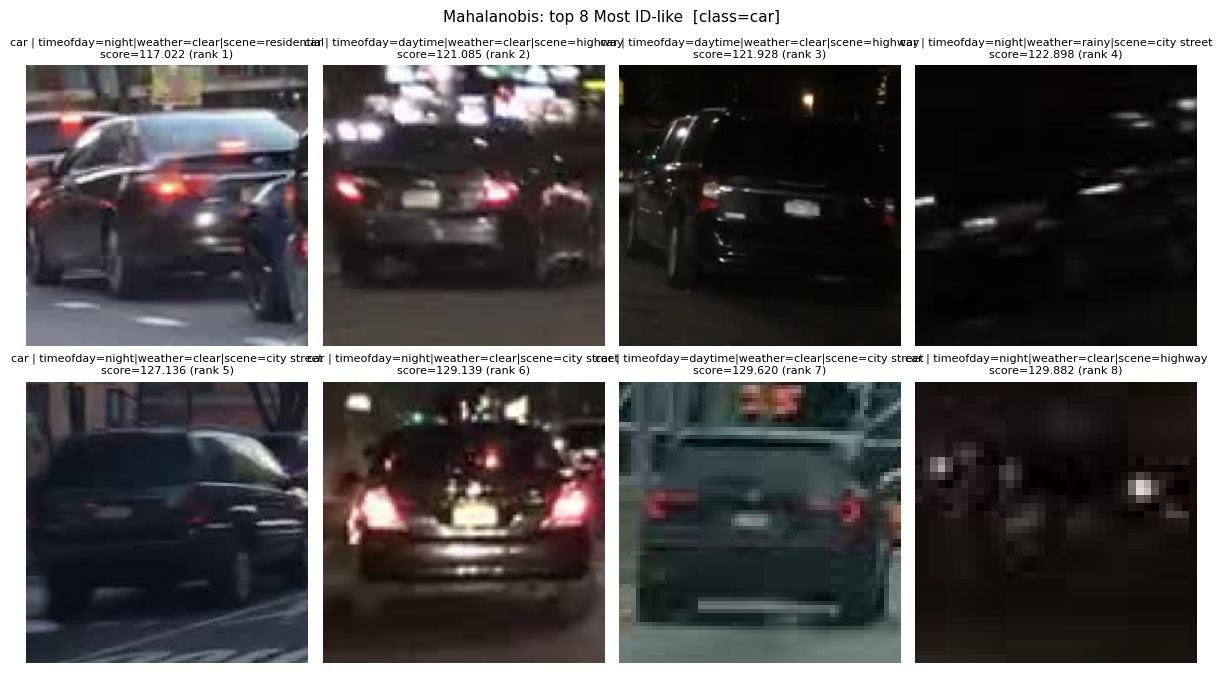

Mahalanobis | person | highest OOD scores


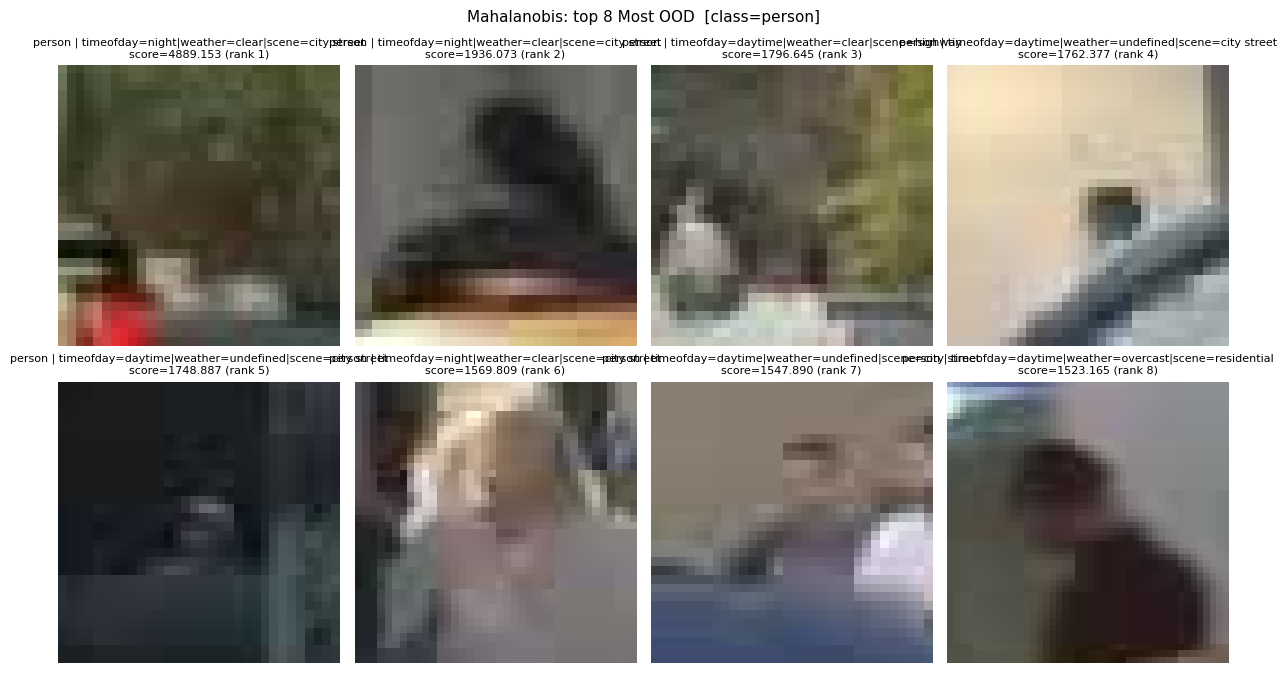

Mahalanobis | person | lowest OOD scores


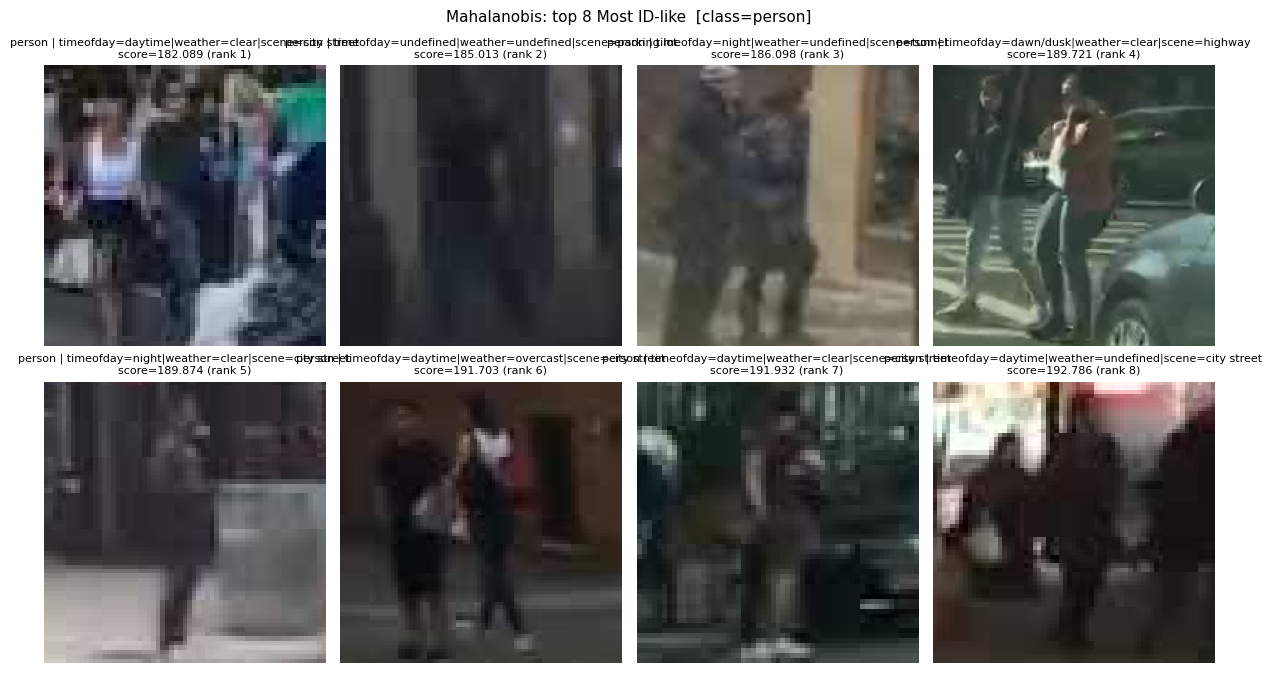

Mahalanobis | traffic sign | highest OOD scores


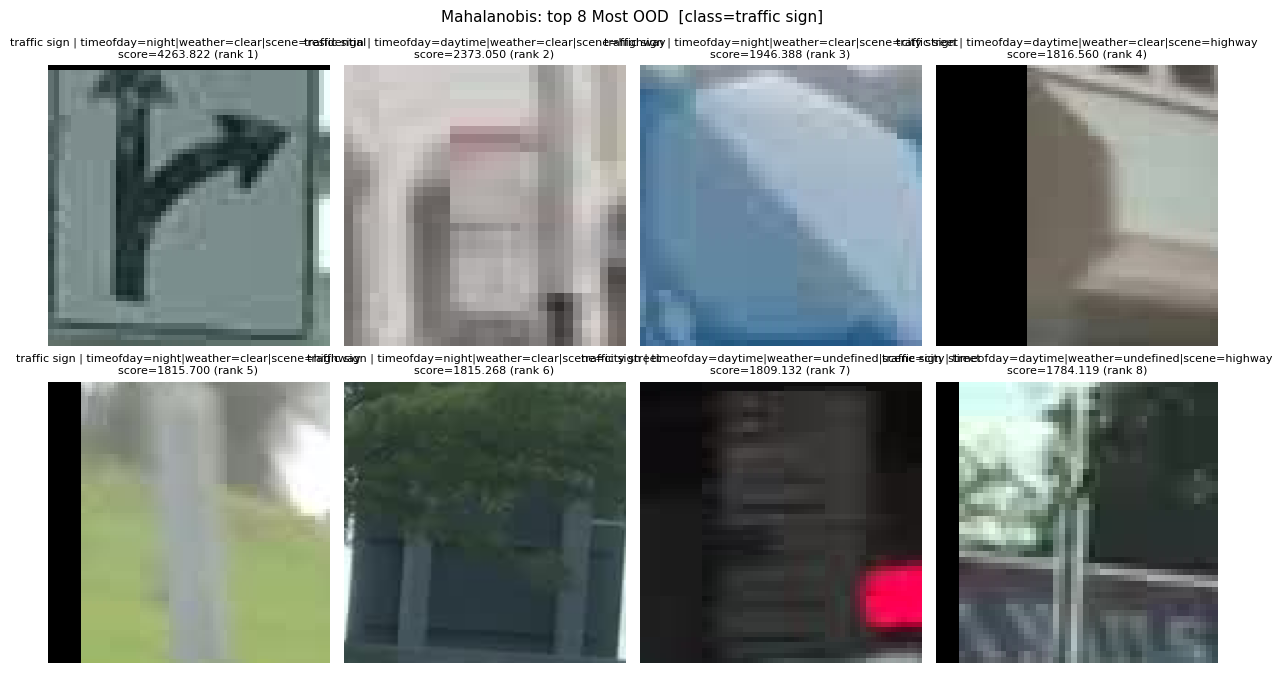

Mahalanobis | traffic sign | lowest OOD scores


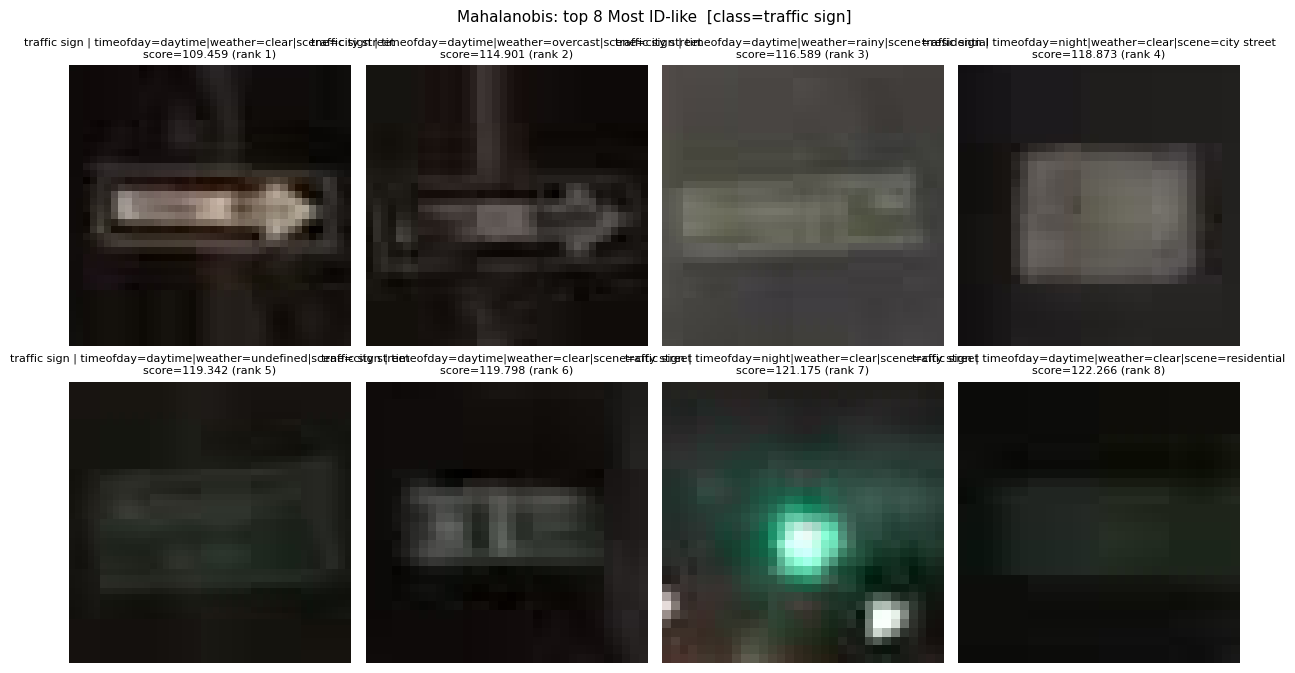

ViM | car | highest OOD scores


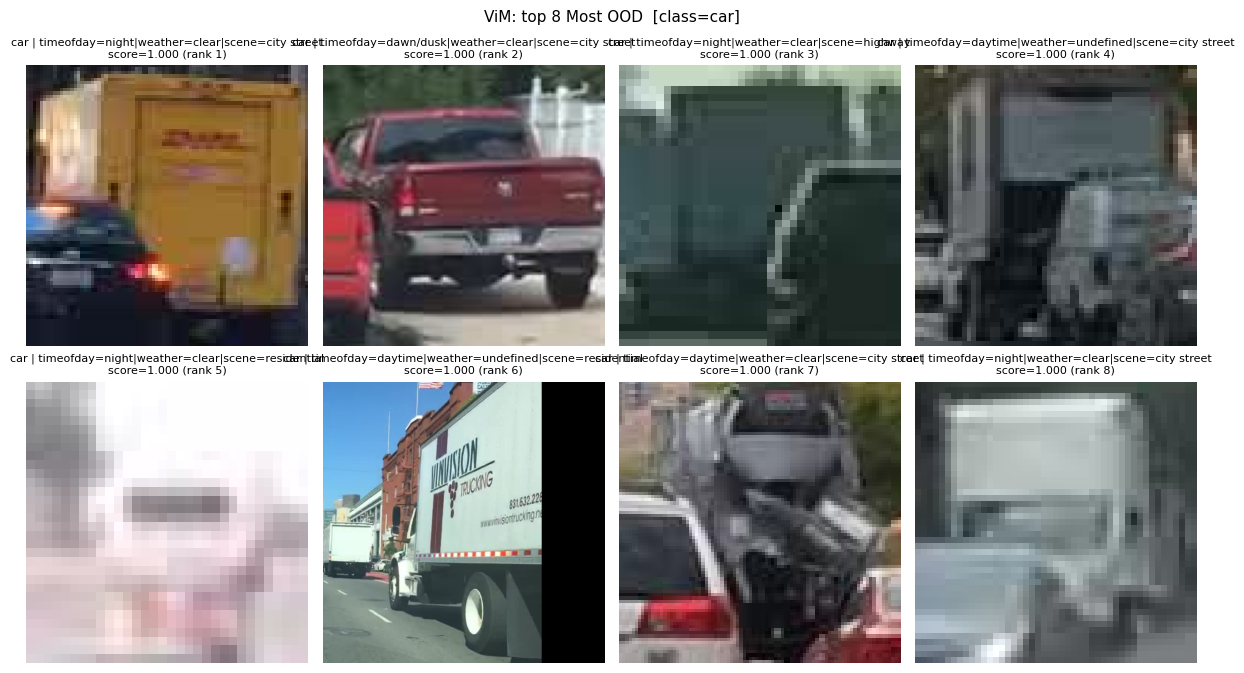

ViM | car | lowest OOD scores


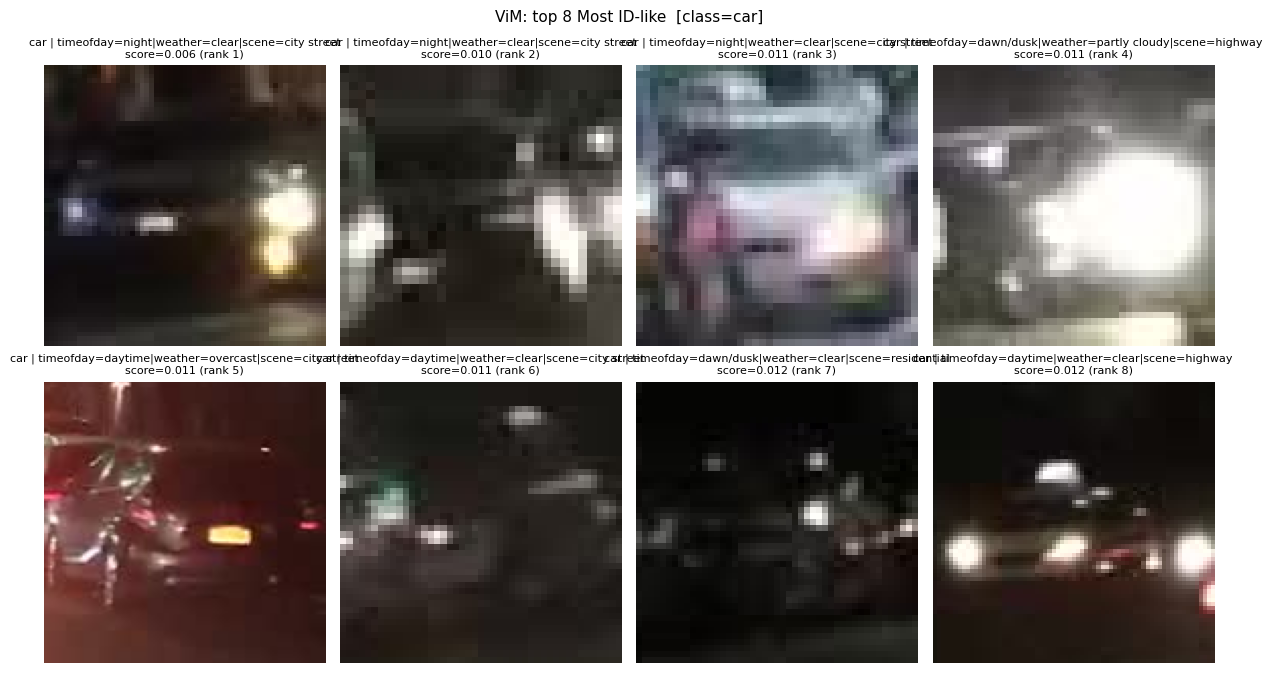

ViM | person | highest OOD scores


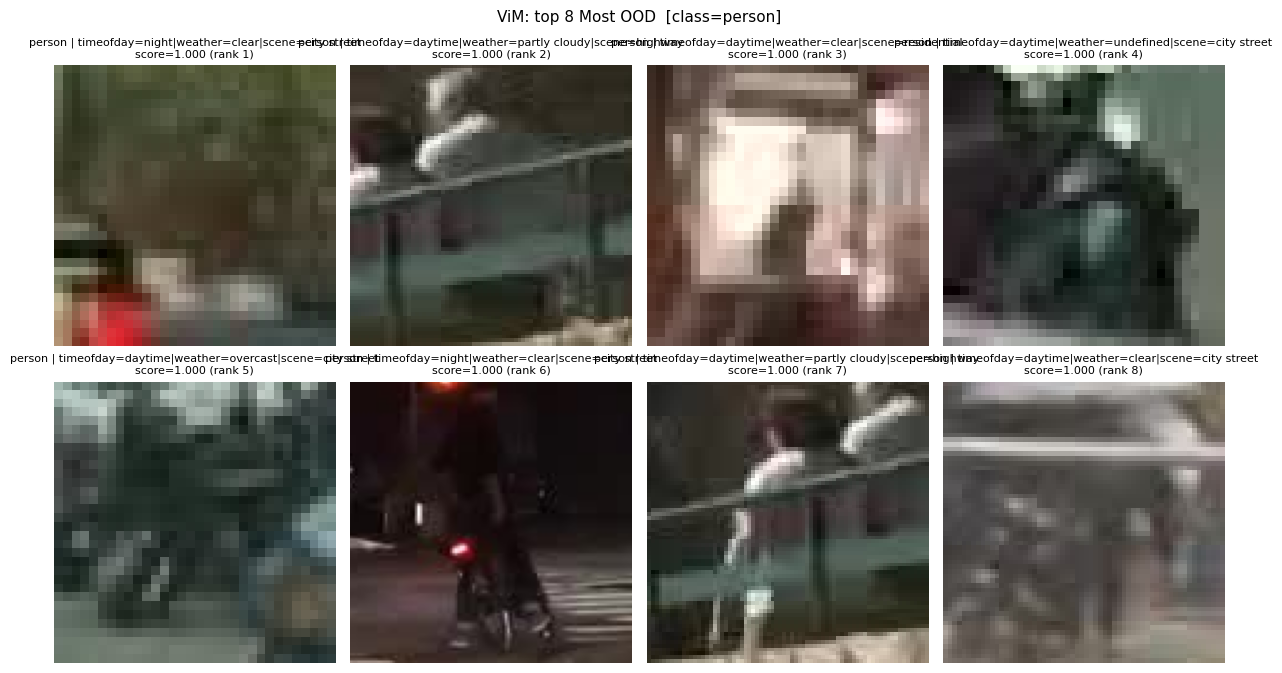

ViM | person | lowest OOD scores


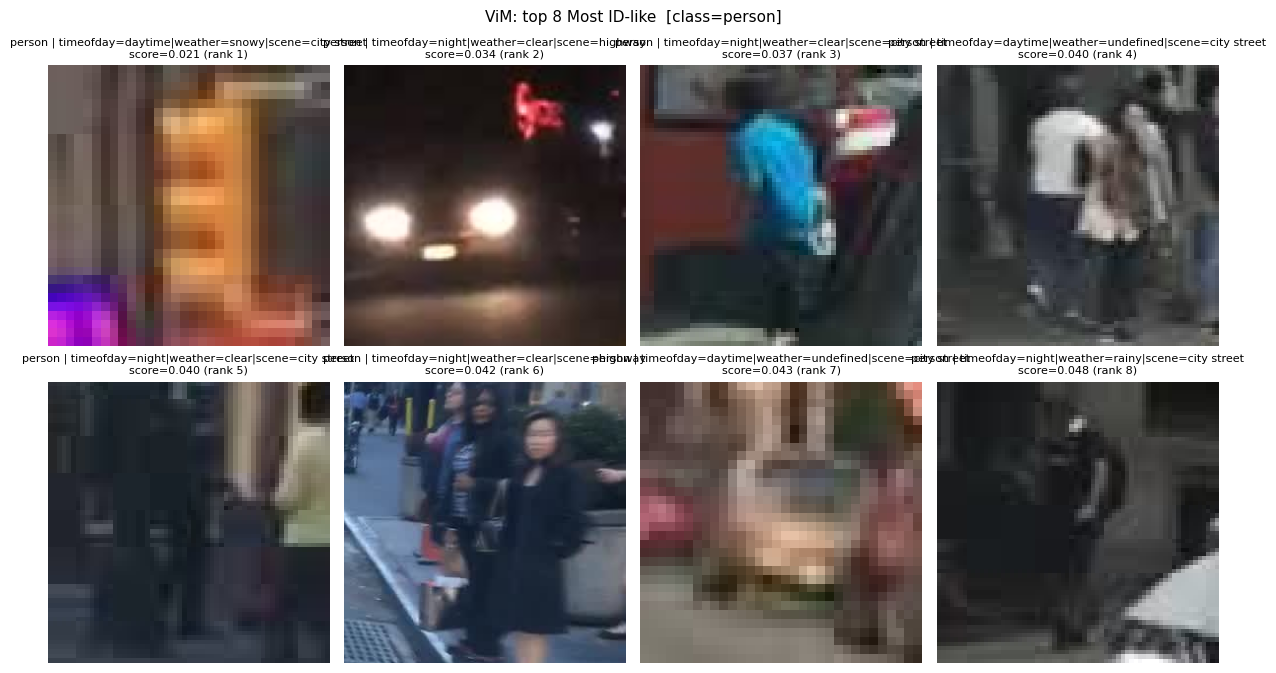

ViM | traffic sign | highest OOD scores


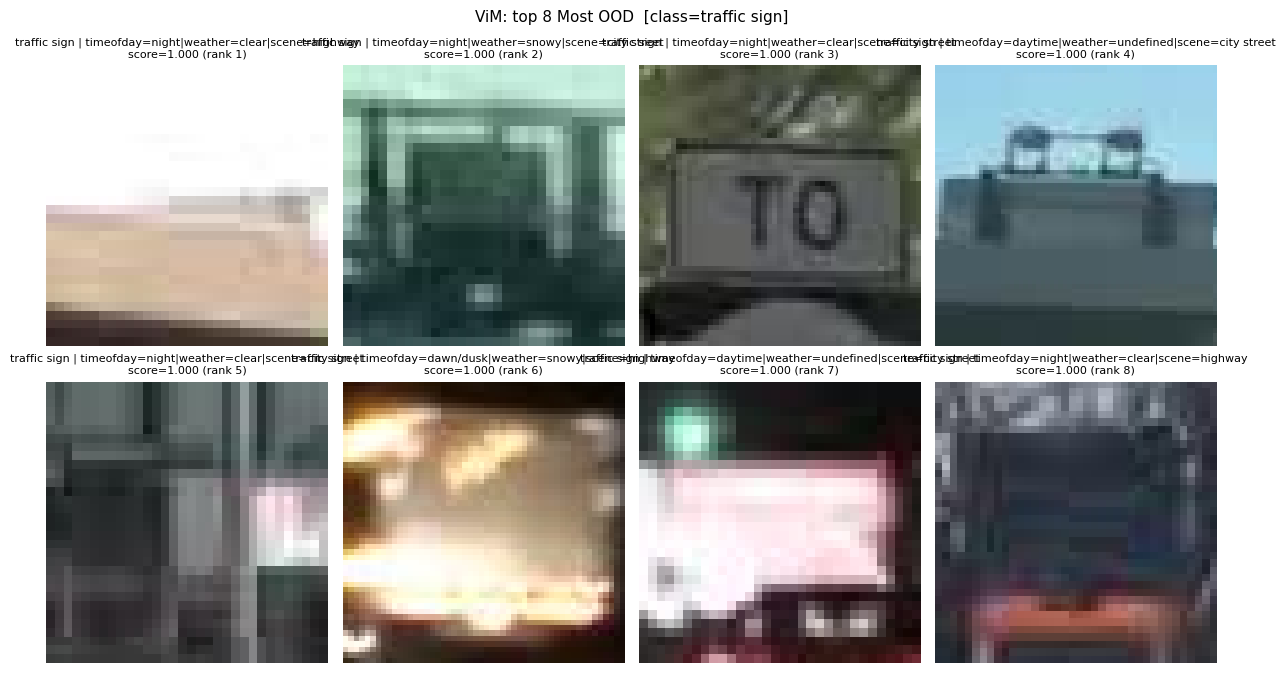

ViM | traffic sign | lowest OOD scores


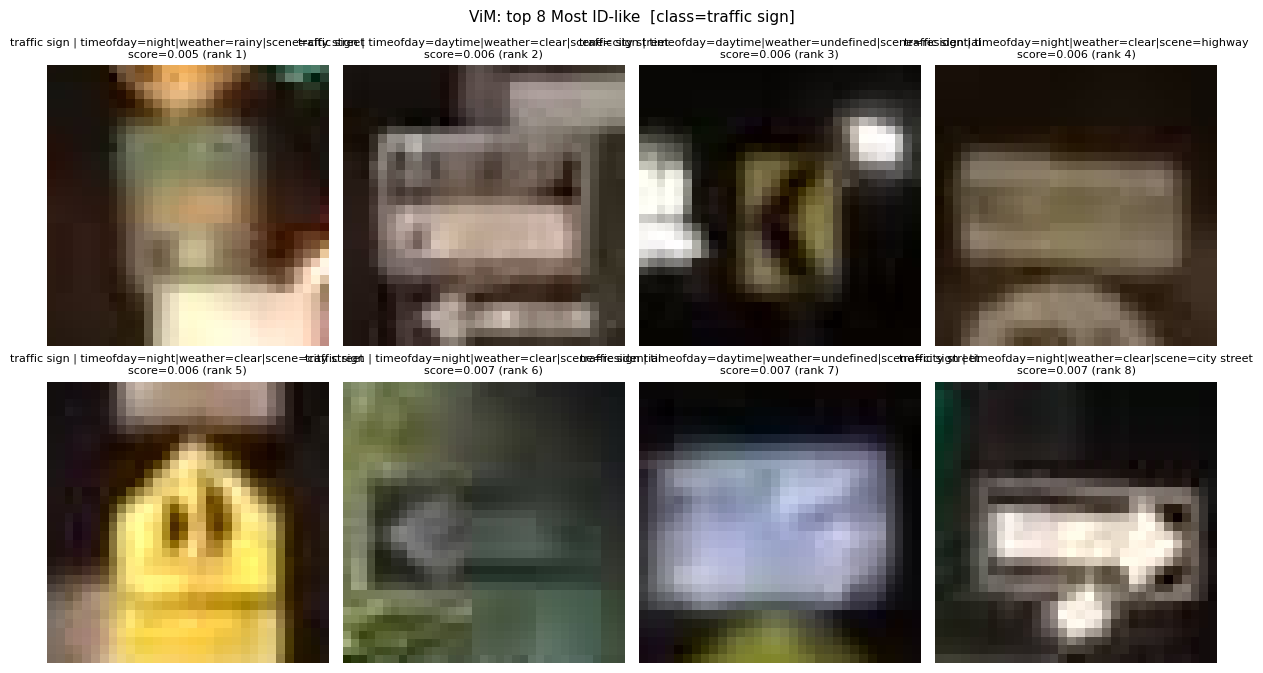

In [13]:
def show_class_extremes(detector: str, class_name: str, *, top_k: int = GRID_K):
    """Show top OOD-like and most ID-like chips for one detector/class."""
    print(f"{detector} | {class_name} | highest OOD scores")
    rank_grid(
        chip_bank,
        detector,
        images=chip_images,
        top_k=top_k,
        direction="ood",
        class_name=class_name,
    )
    plt.show()

    print(f"{detector} | {class_name} | lowest OOD scores")
    rank_grid(
        chip_bank,
        detector,
        images=chip_images,
        top_k=top_k,
        direction="id",
        class_name=class_name,
    )
    plt.show()


for detector_name in GALLERY_DETECTORS:
    if detector_name not in detectors:
        continue
    for cls_name in focus_classes:
        show_class_extremes(detector_name, cls_name)

High-scoring chips tend to correspond to low visibility, blur, truncation, glare,
very small objects, or unusual crops. This suggests chip-level OOD scoring can
be useful for dataset auditing even without explicit OOD labels.

## Inspect A Full Parent Image

Use the ranked tables or grids to pick a chip index. `inspect_chip_parent`
loads the original BDD image, draws the chip box and square crop region, and
prints detector scores plus label metadata.

In [14]:
def chip_summary(chip_idx: int) -> dict:
    chip_idx = int(chip_idx)
    cls_idx = int(class_labels[chip_idx])
    return {
        "chip_idx": chip_idx,
        "class": class_names[cls_idx],
        "image_path": combined_image_paths[chip_idx],
        "box_xyxy": combined_boxes[chip_idx].round(1).tolist(),
        **{name: float(scores[chip_idx]) for name, scores in chip_scores.items()},
    }


def raw_bdd_label_for_chip(chip_idx: int, *, split: str = "val") -> dict:
    """Return the nearest raw BDD100K JSON object for a scored chip."""
    chip_idx = int(chip_idx)
    image_name = Path(combined_image_paths[chip_idx]).name
    target = combined_boxes[chip_idx]
    label_path = BDD_LABEL_ROOT / f"bdd100k_labels_images_{split}.json"

    records = _load_bdd_json(label_path)
    image_rec = next((r for r in records if r.get("name") == image_name), None)
    if image_rec is None:
        raise KeyError(f"{image_name!r} not found in {label_path}")

    best = None
    for obj in image_rec.get("labels", []):
        raw_box = obj.get("box2d")
        if raw_box is None:
            continue
        xyxy = np.asarray(
            [raw_box["x1"], raw_box["y1"], raw_box["x2"], raw_box["y2"]],
            dtype=np.float64,
        )
        l1_delta = float(np.abs(xyxy - target).sum())
        x1, y1 = np.maximum(xyxy[:2], target[:2])
        x2, y2 = np.minimum(xyxy[2:], target[2:])
        inter = max(0.0, float(x2 - x1)) * max(0.0, float(y2 - y1))
        area_a = max(0.0, float(xyxy[2] - xyxy[0])) * max(0.0, float(xyxy[3] - xyxy[1]))
        area_b = max(0.0, float(target[2] - target[0])) * max(0.0, float(target[3] - target[1]))
        union = area_a + area_b - inter
        iou = inter / union if union > 0 else 0.0
        candidate = (l1_delta, -iou, obj, xyxy, iou)
        if best is None or candidate[:2] < best[:2]:
            best = candidate

    if best is None:
        raise ValueError(f"{image_name!r} has no raw box2d labels")

    l1_delta, neg_iou, obj, xyxy, iou = best
    return {
        "chip_idx": chip_idx,
        "notebook_class": class_names[int(class_labels[chip_idx])],
        "raw_category": obj.get("category"),
        "raw_id": obj.get("id"),
        "raw_attributes": obj.get("attributes"),
        "raw_box_xyxy": xyxy.round(3).tolist(),
        "chip_box_xyxy": target.round(3).tolist(),
        "l1_delta": l1_delta,
        "iou": float(iou),
    }


def top_chip_indices(
    detector: str,
    *,
    class_name: str | None = None,
    direction: str = "ood",
    k: int = 10,
) -> np.ndarray:
    if detector not in chip_scores:
        raise KeyError(f"Unknown detector {detector!r}; available: {list(chip_scores)}")
    if direction not in ("ood", "id"):
        raise ValueError("direction must be 'ood' or 'id'")

    mask = np.ones(len(class_labels), dtype=bool)
    if class_name is not None:
        cls_idx = class_names.index(class_name)
        mask &= class_labels == cls_idx

    idx = np.nonzero(mask)[0]
    order = np.argsort(chip_scores[detector][idx])
    if direction == "ood":
        order = order[::-1]
    return idx[order[:k]]


def inspect_chip_parent(
    chip_idx: int,
    *,
    pad: int = 20,
    figsize: tuple[float, float] = (12, 7),
):
    chip_idx = int(chip_idx)
    path = combined_image_paths[chip_idx]
    box = combined_boxes[chip_idx]
    cls_idx = int(class_labels[chip_idx])

    image = Image.open(path).convert("RGB")
    draw = ImageDraw.Draw(image)

    chip_region = square_chip_regions(box[None, :], min_chip_size=MIN_CHIP_SIZE)[0]
    draw.rectangle(tuple(box), outline="lime", width=4)
    draw.rectangle(tuple(chip_region), outline="yellow", width=3)

    print(chip_summary(chip_idx))

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.set_title(f"chip {chip_idx} | {class_names[cls_idx]} | {Path(path).name}")
    ax.axis("off")
    plt.show()

    x1, y1, x2, y2 = chip_region
    w, h = image.size
    crop_box = (
        max(0, int(np.floor(x1)) - pad),
        max(0, int(np.floor(y1)) - pad),
        min(w, int(np.ceil(x2)) + pad),
        min(h, int(np.ceil(y2)) + pad),
    )
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image.crop(crop_box))
    ax.set_title("parent-image crop around chip")
    ax.axis("off")
    plt.show()

Candidate chip indices: [30864, 50292, 20952, 79932, 61589, 46298, 48590, 47182, 20437, 82859]
{'chip_idx': 30864, 'class': 'truck', 'image_path': '/datasets/bdd100k/images/100k/val/ba73ab52-4980c05c.jpg', 'box_xyxy': [742.7, 60.4, 764.2, 117.2], 'Mahalanobis': 359.4059928801769, 'ViM': 0.020058054476976395}


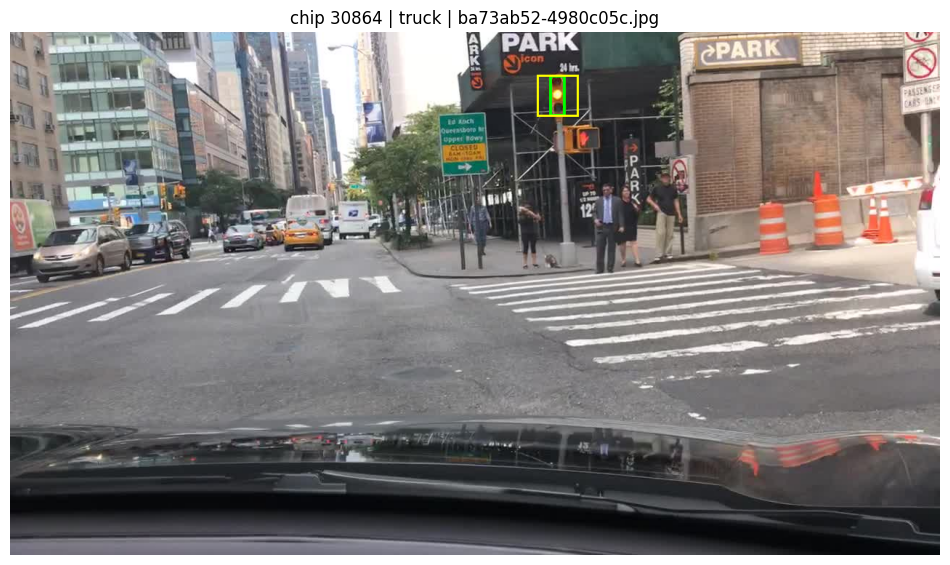

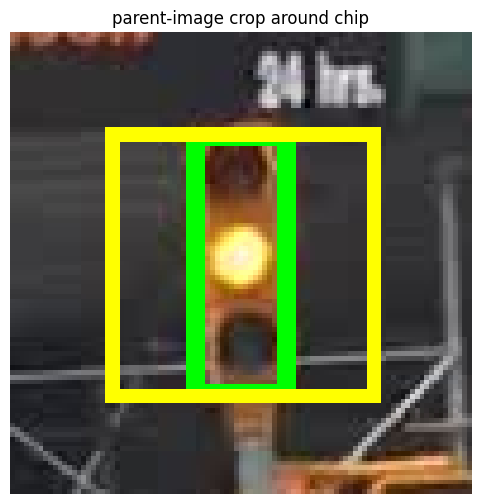

In [42]:
# Example: inspect the top Mahalanobis car chip.
example_indices = top_chip_indices("ViM", class_name="truck", direction="id", k=10)
print("Candidate chip indices:", example_indices.tolist())
inspect_chip_parent(int(example_indices[0]))